In [1]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta,time
from scipy import stats
import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sklearn

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [4]:
userInputData = loadDataFromFile("UserPrevious experiments-preprocessed")
timeSeriesData_BIG = loadDataFromFile("Data:Previous experiments-preprocessed")

C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 79 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\UserPrevious experiments-preprocessed.json
C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data
Loaded 193493 records from C:\Users\Andreas\Documents\PlatformIO\Projects\Diploma Project\dataAnalysis and machine learning\data\Data:Previous experiments-preprocessed.json


In [5]:
# Convert back to timedelta
timeSeriesData_BIG['timestamp'] = pd.to_timedelta(timeSeriesData_BIG['timestamp'], unit='ms')

# Convert back to datetime

timeSeriesData_BIG ["datetime_timestamp"]= timeSeriesData_BIG['datetime_timestamp'].transform(
    lambda x: pd.to_datetime(x, unit='ms')
)


In [6]:
columns_datetime= [
       'date of experiment', 'actual timestamp StartingExperiment',
       'actual timestamp EndingExperiment', ]
columns_timedelta = ['time taken total',
       'timestamp InsertingSource timedelta',
       'time taken after insertion']

userInputData.loc[:,columns_datetime] = userInputData.loc[:,columns_datetime].apply(lambda x:pd.to_datetime(x, unit='ms'))
userInputData.loc[:,columns_timedelta] = userInputData.loc[:,columns_timedelta].apply(lambda x:pd.to_timedelta(x, unit='ms'))

In [7]:
# Split back into dict
dict_of_timeseries = {k: v.drop(columns="keys").reset_index(drop=True) 
             for k, v in timeSeriesData_BIG.groupby("keys")}

In [8]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-01 16:09:41,2025-07-01 15:27:16,2025-07-01 16:14:44,2025-07-01,2025-07-01 15:27:19,2025-07-01 16:14:42,0 days 00:47:23,0 days 00:42:23,2543.0,0 days 00:05:00,-0.95,1.1,NaN,NaN,-1.00,1.05,-0.30,1.05
1,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-02 15:59:29,2025-07-02 15:42:50,2025-07-02 16:04:52,2025-07-02,2025-07-02 15:42:50,2025-07-02 16:04:50,0 days 00:22:00,0 days 00:16:40,1000.0,0 days 00:05:20,-0.95,1.1,NaN,NaN,-1.00,1.05,-0.30,1.05
2,InsertingSourcePollutant,on,None,None,0.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,0.9,None,None,2025-07-03 12:34:32,2025-07-03 12:30:25,2025-07-03 12:45:31,2025-07-03,2025-07-03 12:30:25,2025-07-03 12:45:31,0 days 00:15:06,0 days 00:04:08,248.0,0 days 00:10:58,-0.95,1.6,NaN,NaN,-1.00,1.05,-0.30,1.05
3,InsertingSourcePollutant,on,None,None,0.9,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.8,None,None,2025-07-03 15:53:07,2025-07-03 15:43:27,2025-07-03 15:59:11,2025-07-03,2025-07-03 15:51:40,2025-07-03 15:59:10,0 days 00:07:30,0 days 00:01:28,88.0,0 days 00:06:02,-0.05,1.1,NaN,NaN,-1.00,1.05,-0.30,1.05
4,InsertingSourcePollutant,on,None,None,1.4,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55,NaN,NaN,1.3,None,None,2025-07-09 19:19:19,2025-07-09 19:01:42,2025-07-09 19:27:50,2025-07-09,2025-07-09 19:01:44,2025-07-09 19:27:49,0 days 00:26:05,0 days 00:17:36,1056.0,0 days 00:08:29,-0.55,0.6,NaN,NaN,-1.00,1.05,-0.30,1.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,0.6,0.6,None,None,2025-08-26 13:09:30,2025-08-26 13:02:26,2025-08-26 13:23:48,2025-08-26,2025-08-26 13:02:27,2025-08-26 13:23:47,0 days 00:21:20,0 days 00:07:04,424.0,0 days 00:14:16,-1.25,-1.4,-0.95,1.2,-0.95,1.20,-0.95,1.20
75,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",1.0,0.8,NaN,None,None,2025-08-26 13:42:02,2025-08-26 13:36:44,2025-08-26 13:53:04,2025-08-26,2025-08-26 13:36:46,2025-08-26 13:53:04,0 days 00:16:18,0 days 00:05:17,317.0,0 days 00:11:01,0.85,-1.2,-0.95,1.2,-0.95,1.20,-0.95,1.20
76,InsertingSourcePollutant,on,None,None,NaN,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",NaN,1.8,1.0,None,None,2025-08-26 16:49:11,2025-08-26 16:29:39,2025-08-26 17:11:16,2025-08-26,2025-08-26 16:29:41,2025-08-26 17:11:14,0 days 00:41:33,0 days 00:19:31,1171.0,0 days 00:22:02,-0.85,-0.2,-0.95,1.2,-0.95,1.20,-0.95,1.20
77,InsertingSourcePollutant,on,None,None,0.7,Φαρμακευτικό αλκοόλ 95%,,"Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 ,...",0.9,NaN,NaN,None,None,2025-08-26 18:25:06,2025-08-26 17:56:27,2025-08-26 18:33:20,2025-08-26,2025-08-26 17:56:28,2025-08-26 18:33:18,0 days 00:36:50,0 days 00:28:39,1719.0,0 days 00:08:11,0.95,

In [9]:
userInputData["room"].unique()

array(['Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55',
       'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1',
       'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90'],
      dtype=object)

In [10]:
userInputData_onlyRoomTogether = userInputData.loc[(userInputData["room"] == 'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1') & (userInputData['experimentState']=='InsertingSourcePollutant'),:]
userInputData_onlyRoomTogether = userInputData_onlyRoomTogether.reset_index(names = "keys")
userInputData_onlyRoomTogether

,keys,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,7,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:04:09,2025-07-19 14:59:47,2025-07-19 15:08:10,2025-07-19,2025-07-19 14:59:49,2025-07-19 15:08:09,0 days 00:08:20,0 days 00:04:21,261.0,0 days 00:03:59,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
1,8,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:17:10,2025-07-19 15:14:13,2025-07-19 15:21:23,2025-07-19,2025-07-19 15:14:15,2025-07-19 15:21:21,0 days 00:07:06,0 days 00:02:56,176.0,0 days 00:04:10,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
2,9,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:30:49,2025-07-19 15:25:07,2025-07-19 15:44:28,2025-07-19,2025-07-19 15:25:09,2025-07-19 15:44:27,0 days 00:19:18,0 days 00:05:41,341.0,0 days 00:13:37,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
3,10,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 16:12:54,2025-07-19 16:04:22,2025-07-19 16:21:55,2025-07-19,2025-07-19 16:04:24,2025-07-19 16:21:54,0 days 00:17:30,0 days 00:08:31,511.0,0 days 00:08:59,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
4,11,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 16:46:45,2025-07-19 16:36:03,2025-07-19 16:54:19,2025-07-19,2025-07-19 16:36:04,2025-07-19 16:54:18,0 days 00:18:14,0 days 00:10:42,642.0,0 days 00:07:32,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
5,12,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 17:25:36,2025-07-19 17:05:51,2025-07-19 17:35:58,2025-07-19,2025-07-19 17:05:52,2025-07-19 17:35:57,0 days 00:30:05,0 days 00:19:45,1185.0,0 days 00:10:20,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
6,13,InsertingSourcePollutant,on,None,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 13:46:03,2025-07-20 13:36:41,2025-07-20 14:48:43,2025-07-20,2025-07-20 13:36:42,2025-07-20 14:48:41,0 days 01:11:59,0 days 00:09:22,562.0,0 days 01:02:37,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
7,14,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 15:15:34,2025-07-20 15:04:15,2025-07-20 15:39:22,2025-07-20,2025-07-20 15:04:17,2025-07-20 15:39:20,0 days 00:35:03,0 days 00:11:18,678.0,0 days 00:23:45,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
8,15,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,ανεμιστήρας,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 15:52:33,2025-07-20 15:47:36,2025-07-20 16:08:05,2025-07-20,2025-07-20 15:47:38,2025-07-20 16:08:03,0 days 00:20:25,0 days 00:04:56,296.0,0 days 00:15:29,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
9,16,InsertingSourcePollutant,on,None,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07

In [11]:
timeSeriesData_BIG_onlyRoomTogether = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData_onlyRoomTogether["keys"]),:]
timeSeriesData_BIG_onlyRoomTogether

,keys,timestamp,sensors,VOC,after_insertion,original_value,datetime_timestamp,seconds
23564,7,0 days 00:00:00,Id=2:BME680:breathVocEquivalent,0.680033,False,False,2025-07-19 14:59:49,0
23565,7,0 days 00:00:00,Id=1:BME680:breathVocEquivalent,2.118851,False,True,2025-07-19 14:59:49,0
23566,7,0 days 00:00:01,Id=2:BME680:breathVocEquivalent,0.679083,False,False,2025-07-19 14:59:50,1
23567,7,0 days 00:00:01,Id=1:BME680:breathVocEquivalent,2.125827,False,False,2025-07-19 14:59:50,1
23568,7,0 days 00:00:02,Id=2:BME680:breathVocEquivalent,0.681077,False,True,2025-07-19 14:59:51,2
...,...,...,...,...,...,...,...,...
118197,63,0 days 00:11:22,Id=1:BME680:breathVocEquivalent,0.896960,True,False,2025-07-28 23:00:16,682
118198,63,0 days 00:11:23,Id=2:BME680:breathVocEquivalent,0.648954,True,False,2025-07-28 23:00:17,683
118199,63,0 days 00:11:23,Id=1:BME680:breathVocEquivalent,0.899868,True,False,2025-07-28 23:00:17,683
118200,63,0 days 00:11:24,Id=2:BME680:breathVocEquivalent,0.648606,True,False,2025-07-28 23:00:18,684


In [12]:
min_sec = 30
max_sec = 120
total=min_sec + max_sec 

In [13]:


dict_of_timeseries_onlyRoomTogether_Data = {}

groups_keys = timeSeriesData_BIG_onlyRoomTogether.groupby("keys").groups

for key, indexes_of_the_timeSeriesData_BIG in groups_keys.items(): 
        min_second = (userInputData_onlyRoomTogether.loc[userInputData_onlyRoomTogether["keys"]==key,"timestamp InsertingSource seconds"].iloc[0]) - min_sec
        max_second = (userInputData_onlyRoomTogether.loc[userInputData_onlyRoomTogether["keys"]==key,"timestamp InsertingSource seconds"].iloc[0]) + max_sec
        particular_experiment = timeSeriesData_BIG_onlyRoomTogether.loc[timeSeriesData_BIG_onlyRoomTogether.index.isin(indexes_of_the_timeSeriesData_BIG)]
        mapped_rows = particular_experiment["seconds"].map(lambda x:True if ((x>=min_second) and (x<max_second)) else False) 
        dict_of_timeseries_onlyRoomTogether_Data[key]  =  particular_experiment.loc[mapped_rows,["seconds","sensors","VOC"]] 


In [14]:
dict_of_timeseries_onlyRoomTogether_Data

{7:        seconds                          sensors       VOC
 24026      231  Id=2:BME680:breathVocEquivalent  0.798525
 24027      231  Id=1:BME680:breathVocEquivalent  1.404333
 24028      232  Id=2:BME680:breathVocEquivalent  0.800500
 24029      232  Id=1:BME680:breathVocEquivalent  1.403337
 24030      233  Id=2:BME680:breathVocEquivalent  0.803212
 ...        ...                              ...       ...
 24321      378  Id=1:BME680:breathVocEquivalent  1.313479
 24322      379  Id=2:BME680:breathVocEquivalent  1.074734
 24323      379  Id=1:BME680:breathVocEquivalent  1.311965
 24324      380  Id=2:BME680:breathVocEquivalent  1.078500
 24325      380  Id=1:BME680:breathVocEquivalent  1.307325
 
 [300 rows x 3 columns],
 8:        seconds                          sensors       VOC
 24858      146  Id=1:BME680:breathVocEquivalent  0.574232
 24859      146  Id=2:BME680:breathVocEquivalent  0.576001
 24860      147  Id=1:BME680:breathVocEquivalent  0.576038
 24861      147  Id=2:B

In [15]:
for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
    print(df_data.shape)

(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(212, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(282, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(0, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)
(300, 3)


In [16]:
for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
    data = df_data.pivot(columns='sensors',index='seconds',values="VOC")
    data.columns.name = None
    
    data = data.reset_index(drop=True)
    data.index.name = "seconds"
    
    dict_of_timeseries_onlyRoomTogether_Data[key] = data
    

In [17]:
#dict_of_timeseries_onlyRoomTogether_Data[20]

In [18]:
for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
    print(df_data.shape)

(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(106, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(141, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(0, 0)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)


In [19]:
current_shape = (total, 2)

dict_of_timeseries_onlyRoomTogether_Data = {
    k: v for k, v in dict_of_timeseries_onlyRoomTogether_Data.items()
    if v.shape == current_shape
}
        

In [20]:
for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
    print(df_data.shape)

(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)
(150, 2)


In [21]:
userInputData_onlyRoomTogether

,keys,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,7,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:04:09,2025-07-19 14:59:47,2025-07-19 15:08:10,2025-07-19,2025-07-19 14:59:49,2025-07-19 15:08:09,0 days 00:08:20,0 days 00:04:21,261.0,0 days 00:03:59,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
1,8,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:17:10,2025-07-19 15:14:13,2025-07-19 15:21:23,2025-07-19,2025-07-19 15:14:15,2025-07-19 15:21:21,0 days 00:07:06,0 days 00:02:56,176.0,0 days 00:04:10,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
2,9,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:30:49,2025-07-19 15:25:07,2025-07-19 15:44:28,2025-07-19,2025-07-19 15:25:09,2025-07-19 15:44:27,0 days 00:19:18,0 days 00:05:41,341.0,0 days 00:13:37,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
3,10,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 16:12:54,2025-07-19 16:04:22,2025-07-19 16:21:55,2025-07-19,2025-07-19 16:04:24,2025-07-19 16:21:54,0 days 00:17:30,0 days 00:08:31,511.0,0 days 00:08:59,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
4,11,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 16:46:45,2025-07-19 16:36:03,2025-07-19 16:54:19,2025-07-19,2025-07-19 16:36:04,2025-07-19 16:54:18,0 days 00:18:14,0 days 00:10:42,642.0,0 days 00:07:32,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
5,12,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 17:25:36,2025-07-19 17:05:51,2025-07-19 17:35:58,2025-07-19,2025-07-19 17:05:52,2025-07-19 17:35:57,0 days 00:30:05,0 days 00:19:45,1185.0,0 days 00:10:20,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
6,13,InsertingSourcePollutant,on,None,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 13:46:03,2025-07-20 13:36:41,2025-07-20 14:48:43,2025-07-20,2025-07-20 13:36:42,2025-07-20 14:48:41,0 days 01:11:59,0 days 00:09:22,562.0,0 days 01:02:37,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
7,14,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 15:15:34,2025-07-20 15:04:15,2025-07-20 15:39:22,2025-07-20,2025-07-20 15:04:17,2025-07-20 15:39:20,0 days 00:35:03,0 days 00:11:18,678.0,0 days 00:23:45,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
8,15,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,ανεμιστήρας,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 15:52:33,2025-07-20 15:47:36,2025-07-20 16:08:05,2025-07-20,2025-07-20 15:47:38,2025-07-20 16:08:03,0 days 00:20:25,0 days 00:04:56,296.0,0 days 00:15:29,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
9,16,InsertingSourcePollutant,on,None,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07

In [22]:
dict_of_timeseries_onlyRoomTogether_Data

{7:          Id=1:BME680:breathVocEquivalent  Id=2:BME680:breathVocEquivalent
 seconds                                                                  
 0                               1.404333                         0.798525
 1                               1.403337                         0.800500
 2                               1.402324                         0.803212
 3                               1.402325                         0.806339
 4                               1.403762                         0.809032
 ...                                  ...                              ...
 145                             1.303474                         1.067489
 146                             1.309776                         1.068610
 147                             1.313479                         1.071162
 148                             1.311965                         1.074734
 149                             1.307325                         1.078500
 
 [150 rows x 2 colum

In [23]:
x_time_series = []
y_source_clasiffier = []
for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
       mask = userInputData_onlyRoomTogether["keys"]==key
       y_element = userInputData_onlyRoomTogether.loc[mask,["x axis","y axis"]].to_numpy()
       y_source_clasiffier.append(y_element)
       x_element = df_data.to_numpy()
       x_time_series.append(x_element)

In [24]:
x_time_series

[array([[1.404333  , 0.79852491],
        [1.40333704, 0.80049983],
        [1.40232351, 0.803212  ],
        [1.402325  , 0.80633851],
        [1.40376157, 0.80903176],
        [1.40460311, 0.810313  ],
        [1.402207  , 0.80949032],
        [1.3950601 , 0.80701921],
        [1.38616731, 0.803642  ],
        [1.379663  , 0.79995723],
        [1.37836791, 0.79598835],
        [1.3798481 , 0.791615  ],
        [1.380356  , 0.78703071],
        [1.37737223, 0.78368444],
        [1.37329031, 0.783339  ],
        [1.371732  , 0.78681573],
        [1.374909  , 0.79117008],
        [1.37939283, 0.792516  ],
        [1.380345  , 0.78826429],
        [1.37433464, 0.78101299],
        [1.36356151, 0.774657  ],
        [1.351633  , 0.77215083],
        [1.34165877, 0.77268758],
        [1.33475747, 0.77452   ],
        [1.33155   , 0.77609176],
        [1.33226836, 0.7766103 ],
        [1.33558889, 0.775474  ],
        [1.339799  , 0.7724595 ],
        [1.34349449, 0.7688565 ],
        [1.346

In [25]:
y_source_clasiffier

[array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-1.55, -0.3 ]]),
 array([[-1.55, -0.3 ]]),
 array([[-1.55, -0.3 ]]),
 array([[-1.55, -0.3 ]]),
 array([[1.25, 0.  ]]),
 array([[1.25, 0.  ]]),
 array([[1.25, 0.  ]]),
 array([[1.25, 0.  ]]),
 array([[1.25, 0.  ]]),
 array([[-0.75,  0.2 ]]),
 array([[-0.65, -0.8 ]]),
 array([[-0.65, -0.8 ]

In [26]:
for data in x_time_series:
        # Check if all values are strictly positive
    all_positive = np.all(data > 0)
    print(all_positive)  # True

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [27]:
for i in range(len(x_time_series)):
    x_time_series[i] = np.abs(x_time_series[i])


In [28]:
for data in x_time_series:
        # Check if all values are strictly positive
    all_positive = np.all(data > 0)
    print(all_positive)  # True

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [29]:
X_features = [exp.flatten() for exp in x_time_series]  # shape (n_experiments, 900)

In [30]:
X_features[1].shape

(300,)

In [31]:
y_array = np.vstack(y_source_clasiffier)   # shape (n_experiments, 2)
_, y_labels = np.unique(y_array, axis=0, return_inverse=True)
# now y_labels is 1D, e.g. [0,0,0,0,1,0,1,2,...]

In [32]:
y_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 0, 0, 0, 0, 3, 3, 3, 3, 3, 1, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [33]:
#y_labels = [0 if label != 3 else 3 for label in y_labels]

In [34]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Train classifier
clf = SVC(kernel='rbf')
clf.fit(X_train, y_train)
score =clf.score(X_test, y_test)
print("Test accuracy:", score)

print("Test accuracy:", clf.score(X_test, y_test))

Test accuracy: 0.45454545454545453
Test accuracy: 0.45454545454545453


In [43]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def test_svc(room_name):
    min_sec = 30
    max_sec = 120
    score_results = {}
    
    userInputData_onlyRoomTogether = userInputData.loc[(userInputData["room"] == room_name) & (userInputData['experimentState']=='InsertingSourcePollutant'),:]
    userInputData_onlyRoomTogether = userInputData_onlyRoomTogether.reset_index(names = "keys")
    timeSeriesData_BIG_onlyRoomTogether = timeSeriesData_BIG.loc[timeSeriesData_BIG["keys"].isin(userInputData_onlyRoomTogether["keys"]),:]
    positions = 0
    y_labels = 0
    for max_sec in range(30,300,30):
        
        total=min_sec + max_sec 
        print(f"total seconds:{total}")
        dict_of_timeseries_onlyRoomTogether_Data = {}
        groups_keys = timeSeriesData_BIG_onlyRoomTogether.groupby("keys").groups
        for key, indexes_of_the_timeSeriesData_BIG in groups_keys.items(): 
                min_second = (userInputData_onlyRoomTogether.loc[userInputData_onlyRoomTogether["keys"]==key,"timestamp InsertingSource seconds"].iloc[0]) - min_sec
                max_second = (userInputData_onlyRoomTogether.loc[userInputData_onlyRoomTogether["keys"]==key,"timestamp InsertingSource seconds"].iloc[0]) + max_sec
                particular_experiment = timeSeriesData_BIG_onlyRoomTogether.loc[timeSeriesData_BIG_onlyRoomTogether.index.isin(indexes_of_the_timeSeriesData_BIG)]
                mapped_rows = particular_experiment["seconds"].map(lambda x:True if ((x>=min_second) and (x<max_second)) else False) 
                dict_of_timeseries_onlyRoomTogether_Data[key]  =  particular_experiment.loc[mapped_rows,["seconds","sensors","VOC"]] 
             #   print(dict_of_timeseries_onlyRoomTogether_Data[key].shape)
            
        for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
            data = df_data.pivot(columns='sensors',index='seconds',values="VOC")
            data.columns.name = None
            
            data = data.reset_index(drop=True)
            data.index.name = "seconds"
            dict_of_timeseries_onlyRoomTogether_Data[key] = data
      #  print(f"current_shape{current_shape}")
        
    
        
        current_shape = (total, 2)
    
        dict_of_timeseries_onlyRoomTogether_Data = {
            k: v for k, v in dict_of_timeseries_onlyRoomTogether_Data.items()
            if v.shape == current_shape
        }
            
        x_time_series = []
        y_source_clasiffier = []
    #    print(dict_of_timeseries_onlyRoomTogether_Data)
        for key,df_data in dict_of_timeseries_onlyRoomTogether_Data.items():
               mask = userInputData_onlyRoomTogether["keys"]==key
               y_element = userInputData_onlyRoomTogether.loc[mask,["x axis","y axis"]].to_numpy()
    
               y_source_clasiffier.append(y_element)
               x_element = df_data.to_numpy()
               x_time_series.append(x_element)   
        for i in range(len(x_time_series)):
            x_time_series[i] = np.abs(x_time_series[i])
        
        
      #  print(y_source_clasiffier)
        X_features = [exp.flatten() for exp in x_time_series]
        y_array = np.vstack(y_source_clasiffier)   # shape (n_experiments, 2)
        positions, y_labels = np.unique(y_array, axis=0, return_inverse=True)
        print(f"positions:{positions}")
        print(f"y_labels{y_labels}")
            # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
        )
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        # Train classifier
        clf = SVC(kernel='rbf')
        clf.fit(X_train, y_train)
        score =clf.score(X_test, y_test)
        
        print("Test accuracy:", score)
        y_pred = clf.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')  # nicer colors
    return positions,y_labels 

In [44]:
userInputData["room"].unique()

array(['Κρεβατοκάμαρα id:1 Μ0.95 Α0.85 id:2 Μ0.95 Α1.55',
       'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1',
       'Κρεβατοκάμαρα-Όλοι οι αισθητήρες μαζί Μ:0.80 , Α:0.90'],
      dtype=object)

total seconds:60
positions:[[-1.55 -0.3 ]
 [-0.75  0.2 ]
 [-0.65 -0.8 ]
 [ 1.25  0.  ]]
y_labels[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 0 0 0 0 3 3 3 3 3
 1 2 2 2 2 2 3 3 3 3 3 0 0 0 0 0 0 0]
Test accuracy: 0.45454545454545453
total seconds:90
positions:[[-1.55 -0.3 ]
 [-0.75  0.2 ]
 [-0.65 -0.8 ]
 [ 1.25  0.  ]]
y_labels[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 0 0 0 0 3 3 3 3 3
 1 2 2 2 2 2 3 3 3 3 3 0 0 0 0 0 0 0]
Test accuracy: 0.45454545454545453
total seconds:120
positions:[[-1.55 -0.3 ]
 [-0.75  0.2 ]
 [-0.65 -0.8 ]
 [ 1.25  0.  ]]
y_labels[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 0 0 0 0 3 3 3 3 3 1
 2 2 2 2 2 3 3 3 3 3 0 0 0 0 0 0 0]
Test accuracy: 0.45454545454545453
total seconds:150
positions:[[-1.55 -0.3 ]
 [-0.75  0.2 ]
 [-0.65 -0.8 ]
 [ 1.25  0.  ]]
y_labels[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 0 0 0 0 3 3 3 3 3 1
 2 2 2 2 2 3 3 3 3 3 0 0 0 0 0 0 0]
Test accuracy: 0.45454545454545453
total seconds:180
position

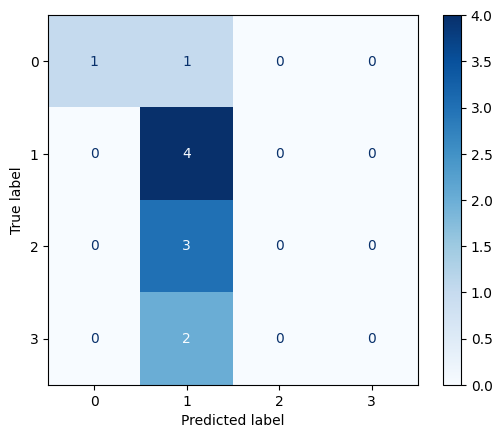

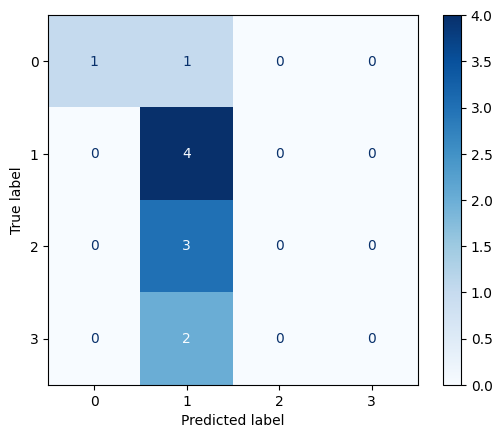

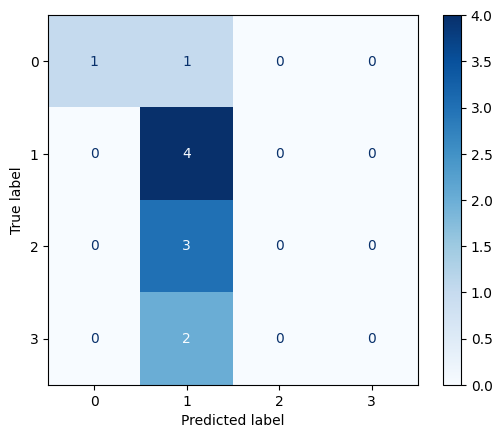

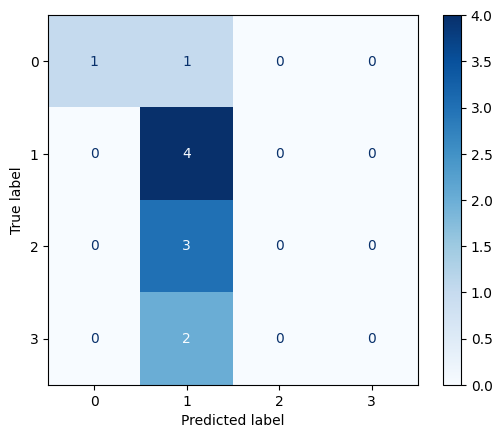

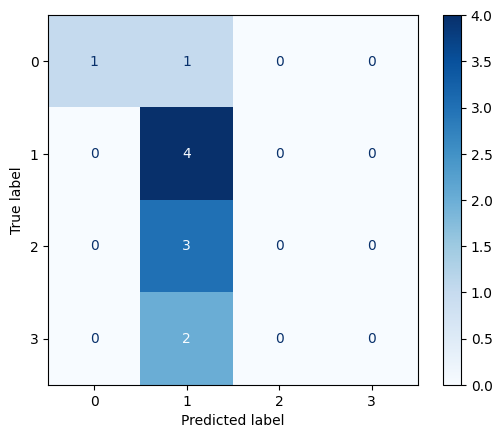

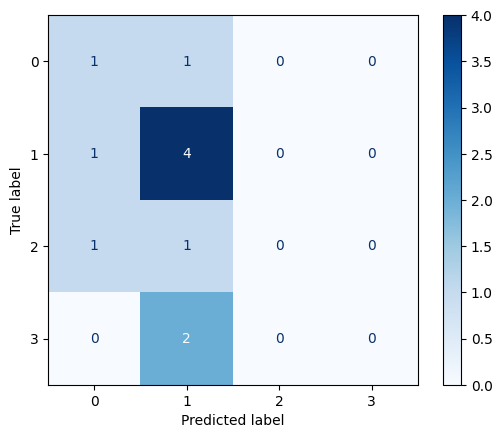

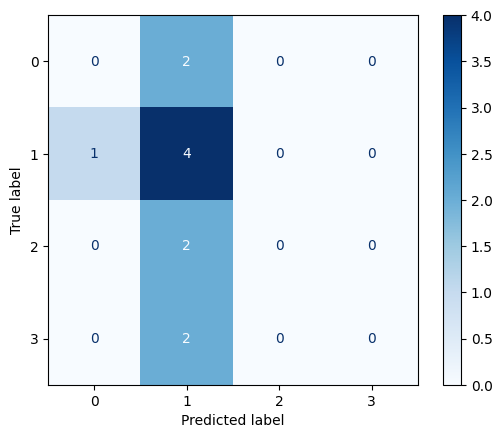

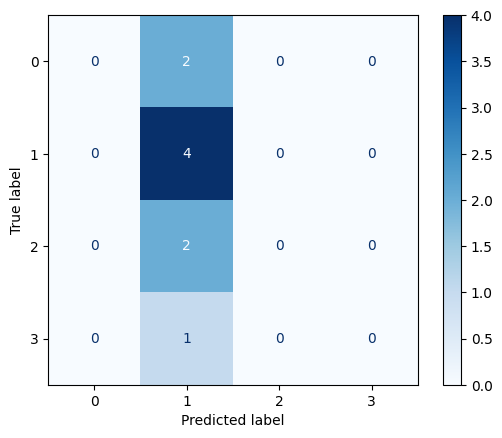

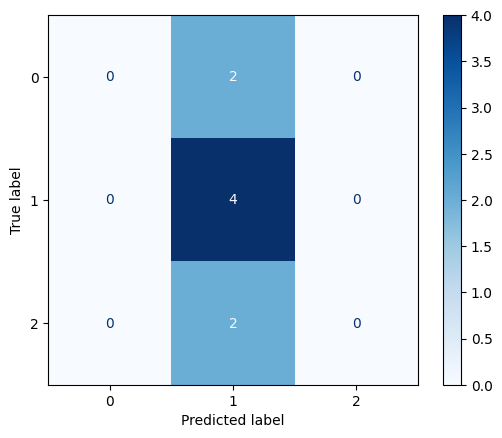

In [45]:
room_name = 'Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1'
positions, y_labels= test_svc(room_name)

In [38]:
userInputData_onlyRoomTogether

,keys,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp InsertingSource,timestamp StartingExperiment,timestamp EndingExperiment,date of experiment,actual timestamp StartingExperiment,actual timestamp EndingExperiment,time taken total,timestamp InsertingSource timedelta,timestamp InsertingSource seconds,time taken after insertion,x axis,y axis,position of Id=0:BME680:breathVocEquivalent-x axis,position of Id=0:BME680:breathVocEquivalent-y axis,position of Id=1:BME680:breathVocEquivalent-x axis,position of Id=1:BME680:breathVocEquivalent-y axis,position of Id=2:BME680:breathVocEquivalent-x axis,position of Id=2:BME680:breathVocEquivalent-y axis
0,7,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:04:09,2025-07-19 14:59:47,2025-07-19 15:08:10,2025-07-19,2025-07-19 14:59:49,2025-07-19 15:08:09,0 days 00:08:20,0 days 00:04:21,261.0,0 days 00:03:59,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
1,8,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:17:10,2025-07-19 15:14:13,2025-07-19 15:21:23,2025-07-19,2025-07-19 15:14:15,2025-07-19 15:21:21,0 days 00:07:06,0 days 00:02:56,176.0,0 days 00:04:10,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
2,9,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 15:30:49,2025-07-19 15:25:07,2025-07-19 15:44:28,2025-07-19,2025-07-19 15:25:09,2025-07-19 15:44:27,0 days 00:19:18,0 days 00:05:41,341.0,0 days 00:13:37,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
3,10,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 16:12:54,2025-07-19 16:04:22,2025-07-19 16:21:55,2025-07-19,2025-07-19 16:04:24,2025-07-19 16:21:54,0 days 00:17:30,0 days 00:08:31,511.0,0 days 00:08:59,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
4,11,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 16:46:45,2025-07-19 16:36:03,2025-07-19 16:54:19,2025-07-19,2025-07-19 16:36:04,2025-07-19 16:54:18,0 days 00:18:14,0 days 00:10:42,642.0,0 days 00:07:32,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
5,12,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-19 17:25:36,2025-07-19 17:05:51,2025-07-19 17:35:58,2025-07-19,2025-07-19 17:05:52,2025-07-19 17:35:57,0 days 00:30:05,0 days 00:19:45,1185.0,0 days 00:10:20,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
6,13,InsertingSourcePollutant,on,None,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 13:46:03,2025-07-20 13:36:41,2025-07-20 14:48:43,2025-07-20,2025-07-20 13:36:42,2025-07-20 14:48:41,0 days 01:11:59,0 days 00:09:22,562.0,0 days 01:02:37,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
7,14,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 15:15:34,2025-07-20 15:04:15,2025-07-20 15:39:22,2025-07-20,2025-07-20 15:04:17,2025-07-20 15:39:20,0 days 00:35:03,0 days 00:11:18,678.0,0 days 00:23:45,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
8,15,InsertingSourcePollutant,on,on,None,1.8,Φαρμακευτικό αλκοόλ 95%,ανεμιστήρας,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07-20 15:52:33,2025-07-20 15:47:36,2025-07-20 16:08:05,2025-07-20,2025-07-20 15:47:38,2025-07-20 16:08:03,0 days 00:20:25,0 days 00:04:56,296.0,0 days 00:15:29,-0.75,0.2,NaN,NaN,-0.65,-1.4,-0.75,1.1
9,16,InsertingSourcePollutant,on,None,None,1.8,Φαρμακευτικό αλκοόλ 95%,,Κρεβατοκάμαρα id:1 Π0.6 Α1.2 id:2 Μ0.8 Α1.1,NaN,NaN,1.1,None,None,2025-07

In [39]:
positions,y_labels

(array([[-1.55, -0.3 ],
        [-0.75,  0.2 ],
        [-0.65, -0.8 ],
        [ 1.25,  0.  ]]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 0, 0, 0, 3, 3, 1, 2, 2, 0, 0, 0, 0, 0, 0], dtype=int64))

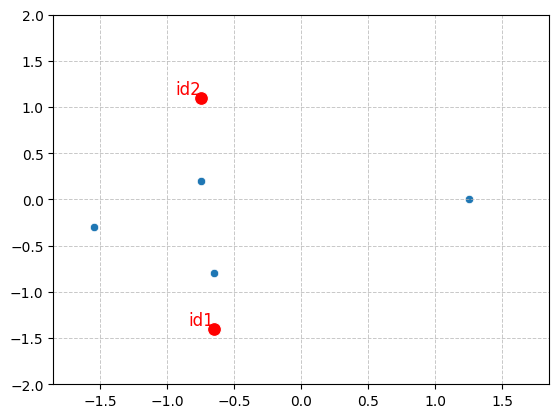

In [41]:
# Extra points
position_of_sensors = userInputData.loc[userInputData["room"] == room_name].iloc[0]

extra_positions = np.array([
    [position_of_sensors["position of Id=1:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=1:BME680:breathVocEquivalent-y axis"]],
    [position_of_sensors["position of Id=2:BME680:breathVocEquivalent-x axis"], position_of_sensors["position of Id=2:BME680:breathVocEquivalent-y axis"]]
])
extra_ids = ["id1", "id2"]

# Example max values (you can replace with user input)
room_length = 2.0
room_width = 1.85 

# Create scatterplot
#sns.scatterplot(x=positions[:,0], y=positions[:,1])


# Add extra points
sns.scatterplot(x=extra_positions[:,0], y=extra_positions[:,1], color='red', s=100)

# Annotate extra points with their IDs
for i, (x, y) in enumerate(extra_positions):
    plt.text(x, y, extra_ids[i], fontsize=12, ha='right', va='bottom', color='red')


# Set axis limits
plt.xlim(-room_width, room_width)
plt.ylim(-room_length, room_length)

# Add grid
plt.grid(True, which="both", linestyle="--", linewidth=0.7, alpha=0.7)

plt.show()

In [42]:
positions,y_labels

(array([[-1.55, -0.3 ],
        [-0.75,  0.2 ],
        [-0.65, -0.8 ],
        [ 1.25,  0.  ]]),
 array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 0, 0, 0, 3, 3, 1, 2, 2, 0, 0, 0, 0, 0, 0], dtype=int64))